# E-commerce Customer Segmentation & Retention Analysis

**Author:** Bamidele Yetunde  |  **Tools:** Python (Pandas, NumPy, Matplotlib)

**Business question:** Which customers drive revenue, how well does the store keep them,
and where should the marketing team focus its retention budget?

**Data:** ~46,000 simulated online-retail transaction lines (Jan 2024 – Dec 2025) with
realistic data-quality problems (duplicates, returns, missing IDs, bad prices, messy text).
The data is synthetic and generated by `generate_data.py`.

**Contents**
1. Load & audit data quality
2. Clean the data
3. Headline KPIs
4. Sales trends & seasonality
5. Products & markets
6. RFM customer segmentation
7. Cohort retention
8. Revenue concentration (Pareto)
9. Key insights & recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.float_format", "{:,.2f}".format)

# one consistent, simple chart style
BLUE, GREY = "#2a78d6", "#8a8984"
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.edgecolor": "#bdbcb6", "font.size": 10,
})

## 1. Load & audit data quality

In [2]:
raw = pd.read_csv("retail_simulated.csv")
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

50,227 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,540066,LIG1025,Lighting Item 26,11,2025-10-03 11:58,31.13,"13,505.00",United Kingdom
1,539695,GIF1032,Gifts Item 33,6,2025-11-29 10:16,4.09,"13,347.00",United States
2,C536812,TEX1005,Textiles Item 06,-12,2024-07-15 18:42,7.40,"12,312.00",United Kingdom
3,538752,HOM1004,Home Decor Item 05,1,2024-12-21 18:31,6.06,"13,021.00",United Kingdom
4,539166,TEX1007,Textiles Item 08,6,2025-06-22 15:08,16.19,"13,171.00",United Kingdom


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50227 entries, 0 to 50226
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    50227 non-null  str    
 1   StockCode    50227 non-null  str    
 2   Description  50227 non-null  str    
 3   Quantity     50227 non-null  int64  
 4   InvoiceDate  50227 non-null  str    
 5   UnitPrice    50227 non-null  float64
 6   CustomerID   48149 non-null  float64
 7   Country      50227 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 3.1 MB


In [4]:
# Data-quality audit: count every problem BEFORE fixing anything
audit = pd.Series({
    "Exact duplicate rows":           raw.duplicated().sum(),
    "Missing CustomerID":             raw["CustomerID"].isna().sum(),
    "Cancelled / returned lines (C)": raw["InvoiceNo"].astype(str).str.startswith("C").sum(),
    "Negative quantity":              (raw["Quantity"] < 0).sum(),
    "Zero or negative price":         (raw["UnitPrice"] <= 0).sum(),
    "Description with extra spaces":  (raw["Description"] != raw["Description"].str.strip()).sum(),
    "Country not in Title Case":      (raw["Country"].str.strip() != raw["Country"].str.strip().str.title()).sum(),
}, name="rows affected")
audit.to_frame()

,rows affected
Exact duplicate rows,497
Missing CustomerID,2078
Cancelled / returned lines (C),979
Negative quantity,979
Zero or negative price,158
Description with extra spaces,2604
Country not in Title Case,1569


## 2. Clean the data

Cleaning rules (each one is a business decision, documented so it can be reviewed):

| Problem | Decision |
|---|---|
| Exact duplicates | Drop – they double-count revenue |
| Missing CustomerID | Keep for revenue totals, exclude from customer-level analysis |
| Cancelled invoices (`C…`) | Separate into a *returns* table to measure return rate |
| Zero / negative prices | Drop – not valid sales (likely adjustments or errors) |
| Messy text | Strip spaces, standardise case |

In [5]:
df = raw.copy()
steps = [("Raw data", len(df))]

df = df.drop_duplicates()
steps.append(("Drop exact duplicates", len(df)))

df = df[df["UnitPrice"] > 0]
steps.append(("Drop zero/negative prices", len(df)))

# standardise text and types
df["Description"] = df["Description"].str.strip().str.title()
df["Country"] = df["Country"].str.strip().str.title()
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype("Int64")

# new columns
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Category"] = df["Description"].str.replace(r" Item \d+$", "", regex=True)
df["Month"] = df["InvoiceDate"].dt.to_period("M")

# split sales vs returns
is_return = df["InvoiceNo"].str.startswith("C")
returns = df[is_return].copy()
sales = df[~is_return].copy()
steps.append(("Sales lines (returns separated)", len(sales)))

# customer-level table needs a known customer
sales_c = sales.dropna(subset=["CustomerID"])
steps.append(("Sales lines with CustomerID", len(sales_c)))

pd.DataFrame(steps, columns=["Step", "Rows"]).set_index("Step")

,Rows
Step,
Raw data,50227
Drop exact duplicates,49730
Drop zero/negative prices,49573
Sales lines (returns separated),48606
Sales lines with CustomerID,46625


In [6]:
# Validation checks - the cleaned data must pass all of these
assert sales.duplicated().sum() == 0
assert (sales["UnitPrice"] > 0).all() and (sales["Quantity"] > 0).all()
assert sales_c["CustomerID"].notna().all()
sales.to_csv("sales_clean.csv", index=False)
print("All validation checks passed. Clean file saved to sales_clean.csv")

All validation checks passed. Clean file saved to sales_clean.csv


## 3. Headline KPIs

In [7]:
total_rev   = sales["Revenue"].sum()
orders      = sales["InvoiceNo"].nunique()
customers   = sales_c["CustomerID"].nunique()
aov         = total_rev / orders
return_rate = -returns["Revenue"].sum() / total_rev
repeat_rate = (sales_c.groupby("CustomerID")["InvoiceNo"].nunique() > 1).mean()

kpis = pd.Series({
    "Total revenue":              f"${total_rev:,.0f}",
    "Orders":                     f"{orders:,}",
    "Customers":                  f"{customers:,}",
    "Average order value (AOV)":  f"${aov:,.2f}",
    "Return rate (% of revenue)": f"{return_rate:.1%}",
    "Repeat-customer rate":       f"{repeat_rate:.1%}",
}, name="Value")
kpis.to_frame()

,Value
Total revenue,"$3,731,015"
Orders,"8,267"
Customers,"2,993"
Average order value (AOV),$451.31
Return rate (% of revenue),1.9%
Repeat-customer rate,38.5%


## 4. Sales trends & seasonality

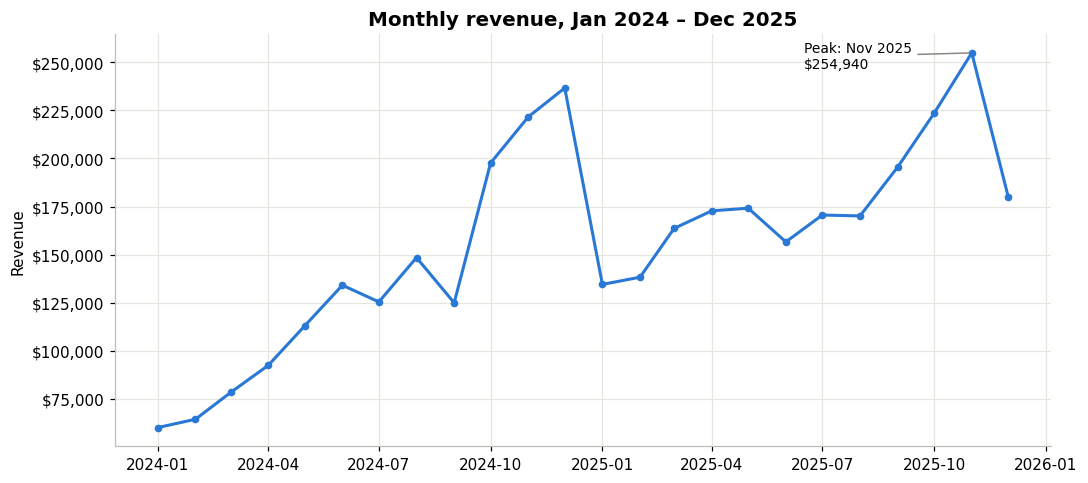

In [8]:
monthly = sales.groupby("Month").agg(Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
monthly["MoM growth"] = monthly["Revenue"].pct_change()

fig, ax = plt.subplots()
x = monthly.index.to_timestamp()
ax.plot(x, monthly["Revenue"], color=BLUE, linewidth=2, marker="o", markersize=4)
peak = monthly["Revenue"].idxmax()
ax.annotate(f"Peak: {peak.strftime('%b %Y')}\n${monthly['Revenue'].max():,.0f}",
            xy=(peak.to_timestamp(), monthly["Revenue"].max()),
            xytext=(-110, -10), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="-", color=GREY))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Monthly revenue, Jan 2024 – Dec 2025")
ax.set_ylabel("Revenue")
plt.tight_layout(); plt.savefig("monthly_revenue.png"); plt.show()

In [9]:
# Seasonality: average revenue by calendar month across both years
season = sales.groupby(sales["InvoiceDate"].dt.month)["Revenue"].sum() / 2
q4_share = season.loc[[10, 11, 12]].sum() / season.sum()
yoy = sales.groupby(sales["InvoiceDate"].dt.year)["Revenue"].sum()
print(f"Q4 (Oct-Dec) share of annual revenue: {q4_share:.1%}")
print(f"Year-over-year revenue growth 2024 -> 2025: {yoy.pct_change().iloc[-1]:.1%}")

Q4 (Oct-Dec) share of annual revenue: 35.2%
Year-over-year revenue growth 2024 -> 2025: 33.7%


## 5. Products & markets

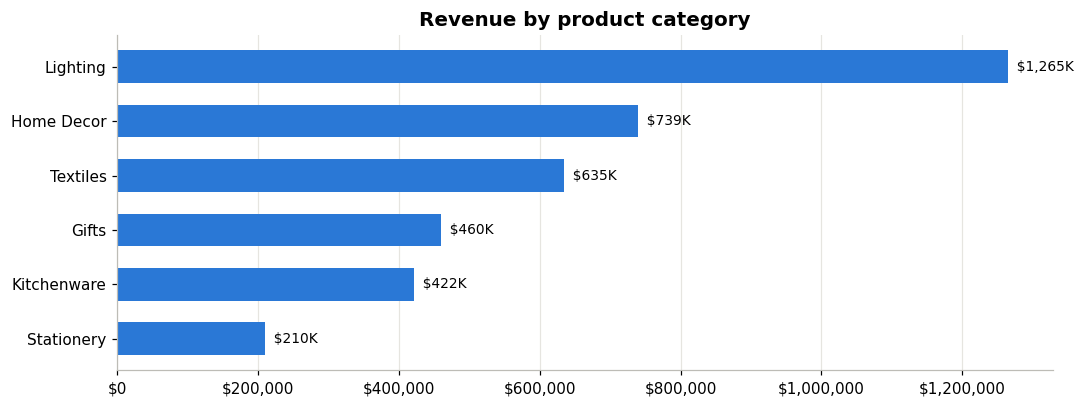

In [10]:
cat = sales.groupby("Category")["Revenue"].sum().sort_values()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.barh(cat.index, cat.values, color=BLUE, height=0.6)
for i, v in enumerate(cat.values):
    ax.text(v, i, f"  ${v/1000:,.0f}K", va="center", fontsize=9)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Revenue by product category"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig("category_revenue.png"); plt.show()

In [11]:
country = (sales.groupby("Country")
           .agg(Revenue=("Revenue", "sum"), Customers=("CustomerID", "nunique"))
           .sort_values("Revenue", ascending=False))
country["Share"] = country["Revenue"] / country["Revenue"].sum()
country["Revenue per customer"] = country["Revenue"] / country["Customers"]
country

,Revenue,Customers,Share,Revenue per customer
Country,,,,
United Kingdom,"2,077,163.52",1658,0.56,"1,252.81"
Germany,"352,600.50",267,0.09,"1,320.60"
France,"230,316.71",218,0.06,"1,056.50"
United States,"185,458.47",113,0.05,"1,641.23"
Netherlands,"182,809.18",154,0.05,"1,187.07"
Nigeria,"161,077.50",125,0.04,"1,288.62"
Ireland,"158,197.33",141,0.04,"1,121.97"
Belgium,"148,952.99",118,0.04,"1,262.31"
Spain,"145,644.28",124,0.04,"1,174.55"


In [12]:
top_products = (sales.groupby("Description")["Revenue"].sum()
                .sort_values(ascending=False))
top10_share = top_products.head(10).sum() / top_products.sum()
print(f"{len(top_products)} products; the top 10 generate {top10_share:.1%} of revenue")
top_products.head(10).to_frame()

240 products; the top 10 generate 19.0% of revenue


,Revenue
Description,
Lighting Item 21,"197,894.50"
Lighting Item 34,"67,637.27"
Home Decor Item 25,"67,290.65"
Textiles Item 15,"61,913.59"
Lighting Item 07,"58,940.50"
Lighting Item 15,"57,106.08"
Lighting Item 26,"53,983.46"
Lighting Item 38,"49,394.45"
Lighting Item 25,"49,360.39"


## 6. RFM customer segmentation

Each customer is scored 1–5 on:
- **Recency** – days since last purchase (recent = better)
- **Frequency** – number of orders
- **Monetary** – total spend

Scores are combined into business-friendly segments the marketing team can act on.

In [13]:
snapshot = sales_c["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = sales_c.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda d: (snapshot - d.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
)

# Recency and Monetary: quintile scores (rank first so ties don't break qcut)
rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
# frequency uses fixed business bins: many customers have exactly 1 order, so quintiles would split ties randomly
rfm["F"] = pd.cut(rfm["Frequency"], bins=[0, 1, 2, 3, 5, np.inf], labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment(row):
    r, f = row["R"], row["F"]
    if r >= 4 and f >= 4:  return "Champions"
    if r >= 3 and f >= 3:  return "Loyal"
    if r >= 4 and f <= 2:  return "New / Promising"
    if r <= 2 and f >= 3:  return "At Risk"
    if r == 3 and f <= 2:  return "Needs Attention"
    return "Hibernating"

rfm["Segment"] = rfm.apply(segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R,F,M,Segment
CustomerID,,,,,,,
12001,591,1,156.47,1,1,1,Hibernating
12002,206,1,619.73,4,1,3,New / Promising
12003,282,5,"1,031.24",3,4,4,Loyal
12004,257,1,611.82,3,1,3,Needs Attention
12005,517,1,662.11,1,1,3,Hibernating


In [14]:
seg = (rfm.groupby("Segment")
       .agg(Customers=("Monetary", "size"), Revenue=("Monetary", "sum"),
            Avg_recency_days=("Recency", "mean"), Avg_orders=("Frequency", "mean"),
            Avg_spend=("Monetary", "mean"))
       .sort_values("Revenue", ascending=False))
seg["% customers"] = seg["Customers"] / seg["Customers"].sum()
seg["% revenue"]   = seg["Revenue"] / seg["Revenue"].sum()
seg

,Customers,Revenue,Avg_recency_days,Avg_orders,Avg_spend,% customers,% revenue
Segment,,,,,,,
Champions,403,"1,499,486.93",65.09,8.63,"3,720.81",0.13,0.42
Loyal,238,"547,186.03",205.08,5.24,"2,299.10",0.08,0.15
Hibernating,1019,"501,021.70",533.12,1.10,491.68,0.34,0.14
At Risk,175,"431,320.05",461.61,5.69,"2,464.69",0.06,0.12
New / Promising,709,"367,269.12",114.41,1.22,518.01,0.24,0.10
Needs Attention,449,"227,465.17",291.55,1.16,506.60,0.15,0.06


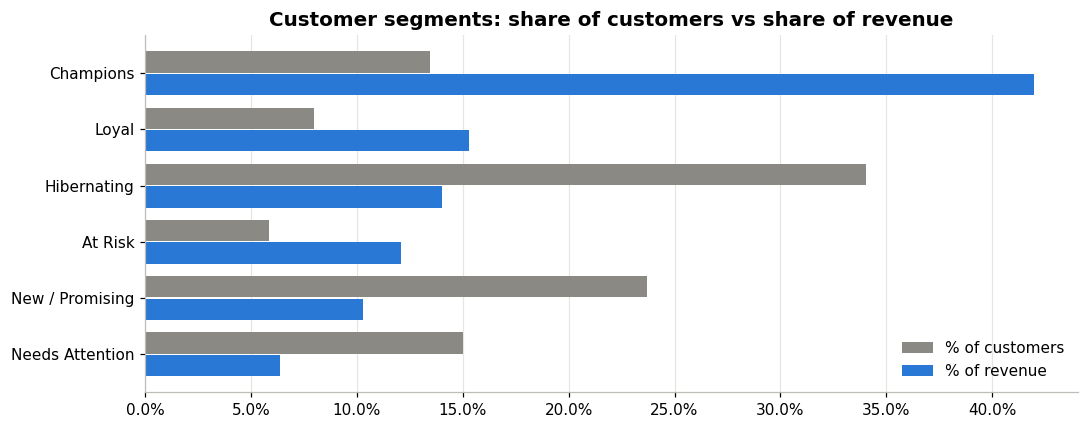

In [15]:
order = seg.index[::-1]
fig, ax = plt.subplots(figsize=(10, 4))
y = np.arange(len(order))
ax.barh(y + 0.2, seg.loc[order, "% customers"], height=0.38, color=GREY, label="% of customers")
ax.barh(y - 0.2, seg.loc[order, "% revenue"], height=0.38, color=BLUE, label="% of revenue")
ax.set_yticks(y, order); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Customer segments: share of customers vs share of revenue")
ax.legend(frameon=False, loc="lower right"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig("rfm_segments.png"); plt.show()

## 7. Cohort retention

Customers are grouped by the month of their **first** purchase. The heatmap shows what
share of each cohort placed another order 1, 2, 3 … months later.

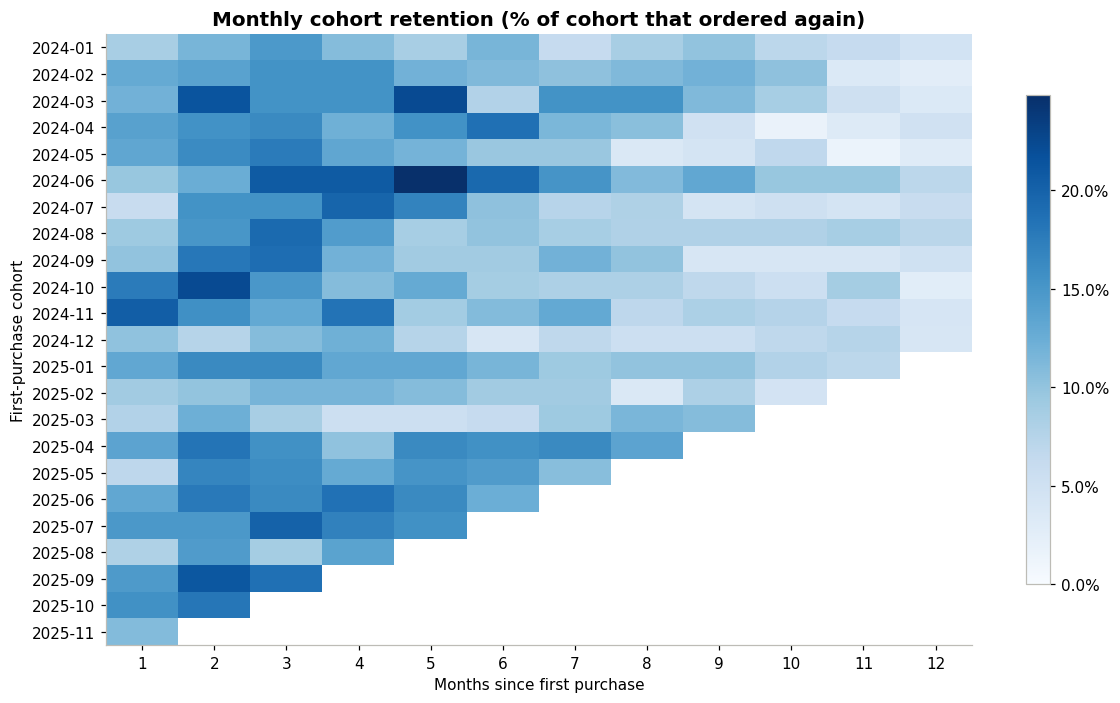

In [16]:
first = sales_c.groupby("CustomerID")["Month"].min().rename("Cohort")
c = sales_c.join(first, on="CustomerID")
c["Period"] = (c["Month"] - c["Cohort"]).apply(lambda p: p.n)

counts = c.groupby(["Cohort", "Period"])["CustomerID"].nunique().unstack()
retention = counts.div(counts[0], axis=0)
ret12 = retention.loc[:, 1:12]

fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(ret12.values, cmap="Blues", aspect="auto", vmin=0, vmax=ret12.max().max())
ax.set_xticks(range(ret12.shape[1]), ret12.columns)
ax.set_yticks(range(len(ret12)), [str(p) for p in ret12.index])
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("First-purchase cohort")
ax.set_title("Monthly cohort retention (% of cohort that ordered again)")
ax.grid(False)
fig.colorbar(im, format=mtick.PercentFormatter(1.0), shrink=0.8)
plt.tight_layout(); plt.savefig("cohort_retention.png"); plt.show()

In [17]:
m1 = retention[1].mean()
m3 = retention[3].mean()
ever_returned = (sales_c.groupby("CustomerID")["Month"].nunique() > 1).mean()
print(f"Average month-1 retention: {m1:.1%}")
print(f"Average month-3 retention: {m3:.1%}")
print(f"Customers who ever came back in a later month: {ever_returned:.1%}")

Average month-1 retention: 11.8%
Average month-3 retention: 15.4%
Customers who ever came back in a later month: 37.8%


## 8. Revenue concentration (Pareto)

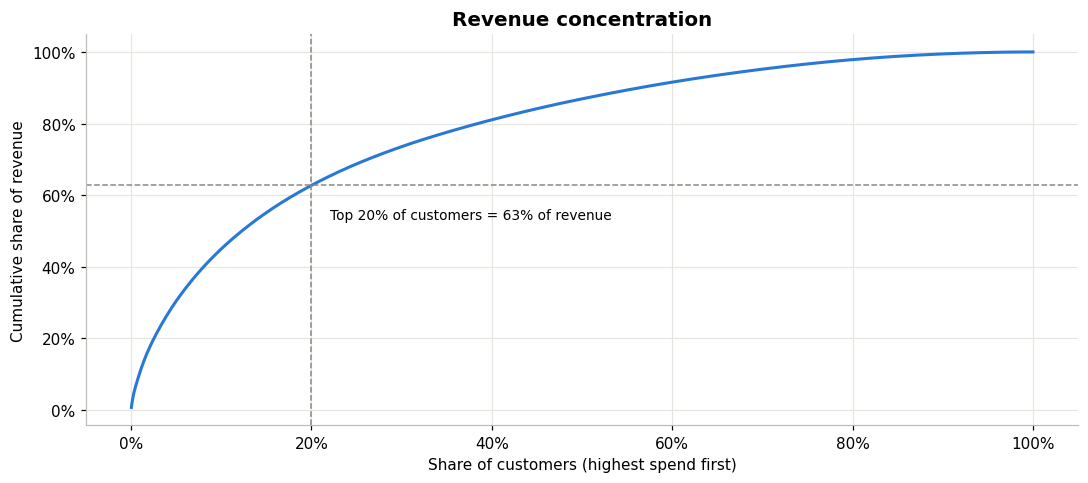

In [18]:
spend = rfm["Monetary"].sort_values(ascending=False)
cum = spend.cumsum() / spend.sum()
top20_share = cum.iloc[int(len(cum) * 0.2) - 1]

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(cum) + 1) / len(cum), cum.values, color=BLUE, linewidth=2)
ax.axvline(0.2, color=GREY, linestyle="--", linewidth=1)
ax.axhline(top20_share, color=GREY, linestyle="--", linewidth=1)
ax.annotate(f"Top 20% of customers = {top20_share:.0%} of revenue", xy=(0.2, top20_share),
            xytext=(12, -22), textcoords="offset points", fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Share of customers (highest spend first)"); ax.set_ylabel("Cumulative share of revenue")
ax.set_title("Revenue concentration")
plt.tight_layout(); plt.savefig("pareto.png"); plt.show()

## 9. Key insights & recommendations

**What the data says**

1. **Revenue is concentrated in a small, loyal group.** *Champions* are 13% of customers but
   generate 42% of revenue, and the top 20% of customers generate 63%.
2. **A high-value group is slipping away.** 175 *At Risk* customers used to order often
   (about 5.7 orders each) but have not bought in about 15 months. They account for $431K (12%)
   of past revenue.
3. **Most customers never come back.** Only 12% of new customers order again in their second
   month, and 62% never return after their first month. The repeat-customer rate is 38.5%.
4. **Sales are strongly seasonal.** Q4 (Oct–Dec) brings 35% of annual revenue, peaking in
   November. Revenue grew 34% year over year as the customer base grew.
5. **Lighting leads the product range** with 34% of revenue. The UK is the largest market (56%),
   and US customers spend the most per head ($1,641 vs. $1,253 in the UK).

**Recommendations**

- **Win back At Risk customers first.** Send them a personalised re-engagement campaign
  before Q4. Winning back even 20% of them could recover about $86K, based on their past spend.
- **Protect Champions** with a loyalty or early-access programme, because losing a few of them
  hurts revenue the most.
- **Fix the second purchase.** Run a post-purchase email flow with a time-limited offer in the
  first 30 days to lift month-1 retention.
- **Plan stock and marketing budget around the Q4 peak,** especially for Lighting.
- **Test more acquisition in the US,** where customers spend the most.

*Limitation: the data is simulated, so these findings demonstrate the method rather than
describe a real business.*

In [19]:
# One-line summary of the numbers used in the README and CV
champ = seg.loc["Champions"]; risk = seg.loc["At Risk"]
print(f"Cleaned {len(raw):,} rows -> {len(sales_c):,} analysis-ready customer sales lines")
print(f"{customers:,} customers | ${total_rev:,.0f} revenue | AOV ${aov:,.2f}")
print(f"Champions: {champ['% customers']:.0%} of customers, {champ['% revenue']:.0%} of revenue")
print(f"At Risk: {int(risk['Customers'])} customers worth ${risk['Revenue']:,.0f} in past revenue")
print(f"Top 20% of customers = {top20_share:.0%} of revenue | month-1 retention {m1:.0%}")

Cleaned 50,227 rows -> 46,625 analysis-ready customer sales lines
2,993 customers | $3,731,015 revenue | AOV $451.31
Champions: 13% of customers, 42% of revenue
At Risk: 175 customers worth $431,320 in past revenue
Top 20% of customers = 63% of revenue | month-1 retention 12%
